# Demo

A demostration script for the ECLYPSE network simulator extension.

This script validates the implementation of the M/M/1 queuing model,
physical link parameters, and routing tables by simulating a "bottleneck"
scenario.

It sets up a topology:

- Sensor → Gateway
- Gateway → R1
- Gateway → R2
- R1 → R2
- R1 → R3
- R2 → R3
- R3 → Cloud

It defines traffic flows,
and measures the end-to-end packet delays to demonstrate the emergence of
queuing congestion.

In [1]:
import time
from eclypse.remote.service import Service
from mm1_infrastructure import MM1Infrastructure
from network_application import NetworkAwareApplication
from NetworkSimulation import NetworkSimulation
import pandas as pd
import matplotlib.pyplot as plt
import random
random.seed(42)

**DemoService** is a placeholder service to represent application endpoints (e.g. Sensors, Cloud).

In this network-focused simulation, services do not perform internal computation (CPU/RAM logic). They serve as anchors in the application graph to define the source and destination of network flows.

In [2]:
class DemoService(Service):
    def __init__(self, name):
        super().__init__(name)
        self.step_callback = None

    async def step(self):
        pass

In [ ]:
from eclypse.placement.strategies import RandomStrategy

print("1. Setting up Infrastructure...")
infra = MM1Infrastructure("IoT_Network")

nodi_infrastruttura = ["Sensor", "Gateway", "R1", "R2", "R3", "Cloud"]
for nodo in nodi_infrastruttura:
    infra.add_node(nodo)


# Access Link (Sensor -> Gateway): 100 Mbps, 1 km
infra.add_physical_link("Sensor", "Gateway", bandwidth_mbps=100, length_km=1)

# Core Network Links: 50 Mbps
infra.add_physical_link("Gateway", "R1", bandwidth_mbps=50, length_km=5)
infra.add_physical_link("Gateway", "R2", bandwidth_mbps=50, length_km=5)
infra.add_physical_link("R1", "R2", bandwidth_mbps=50, length_km=2)
infra.add_physical_link("R1", "R3", bandwidth_mbps=50, length_km=10)
infra.add_physical_link("R2", "R3", bandwidth_mbps=50, length_km=10)

# Bottleneck Link (R3 -> Cloud): 10 Mbps, 50 km 
infra.add_physical_link("R3", "Cloud", bandwidth_mbps=10, length_km=50)

# Installation of shortest path routes (default behavior)
infra.install_shortest_path_routes()


print("2. Setting up Application (Video Stream)...")
app = NetworkAwareApplication("VideoApp")

app.add_service(DemoService("Sensor"))
app.add_service(DemoService("Cloud"))

# STRESS TEST PARAMS:
# Packet Size = 1500 Byte -> Service Time on 10Mbps = 1.2 ms
# Rate = 1 pkt / tick.
# We send every a 0.5ms, but we're busy 1.2ms -> congestion at node R3
app.add_flow("Sensor", "Cloud", packet_size_bytes=1500, packets_per_tick=1)


print("3. Initializing Simulation...")
sim = NetworkSimulation(infra)

strategy = RandomStrategy(seed=42)
sim.register(app, placement_strategy=strategy)

# Execution
df = sim.run_network_ticks(duration_ticks=100, tick_duration_s=0.0005)

print("Simulation completed!")

1. Setting up Infrastructure...
2. Setting up Application (Video Stream)...
Add edge flow Sensor->Cloud: 1 pkt/tick, size 1500B
3. Initializing Simulation...
16:58:48.108 | WARNING | SimulationConfig - Manual simulation required!
[  0.000124s] | Packet: 1     | Link: Sensor -> Gateway | Status: FINISHED
[  0.000396s] | Packet: 1     | Link: Gateway -> R1  | Status: FINISHED
[  0.000709s] | Packet: 1     | Link: R1  -> R3  | Status: FINISHED
[  0.000718s] | Packet: 2     | Link: Sensor -> Gateway | Status: FINISHED
[  0.000839s] | Packet: 2     | Link: Gateway -> R1  | Status: FINISHED
[  0.001036s] | Packet: 2     | Link: R1  -> R3  | Status: FINISHED
[  0.001579s] | Packet: 3     | Link: Sensor -> Gateway | Status: FINISHED
[  0.002157s] | Packet: 3     | Link: R1  -> R3  | Status: FINISHED
[  0.001612s] | Packet: 4     | Link: Sensor -> Gateway | Status: FINISHED
[  0.001963s] | Packet: 3     | Link: Gateway -> R1  | Status: FINISHED
[  0.002068s] | Packet: 4     | Link: Gateway -> R

In [4]:
df

,Tick,Packet_ID,App,Src,Dst,Start_Time,End_Time,Total_Delay_ms,Hops_Count,Hops_Details
0,1,1,,Sensor,Cloud,0.0000,0.003610,3.610170,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
1,2,2,,Sensor,Cloud,0.0005,0.008560,8.059975,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
2,3,3,,Sensor,Cloud,0.0010,0.008877,7.877403,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
3,4,4,,Sensor,Cloud,0.0015,0.010631,9.131149,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
4,5,5,,Sensor,Cloud,0.0020,0.010734,8.733674,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
...,...,...,...,...,...,...,...,...,...,...
95,96,96,,Sensor,Cloud,0.0475,0.104182,56.681851,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
96,97,97,,Sensor,Cloud,0.0480,0.105900,57.900386,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
97,98,98,,Sensor,Cloud,0.0485,0.107992,59.492046,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."
98,99,99,,Sensor,Cloud,0.0490,0.108771,59.770633,4,"[{'hop': 'Sensor->Gateway', 'processing_ms': 0..."


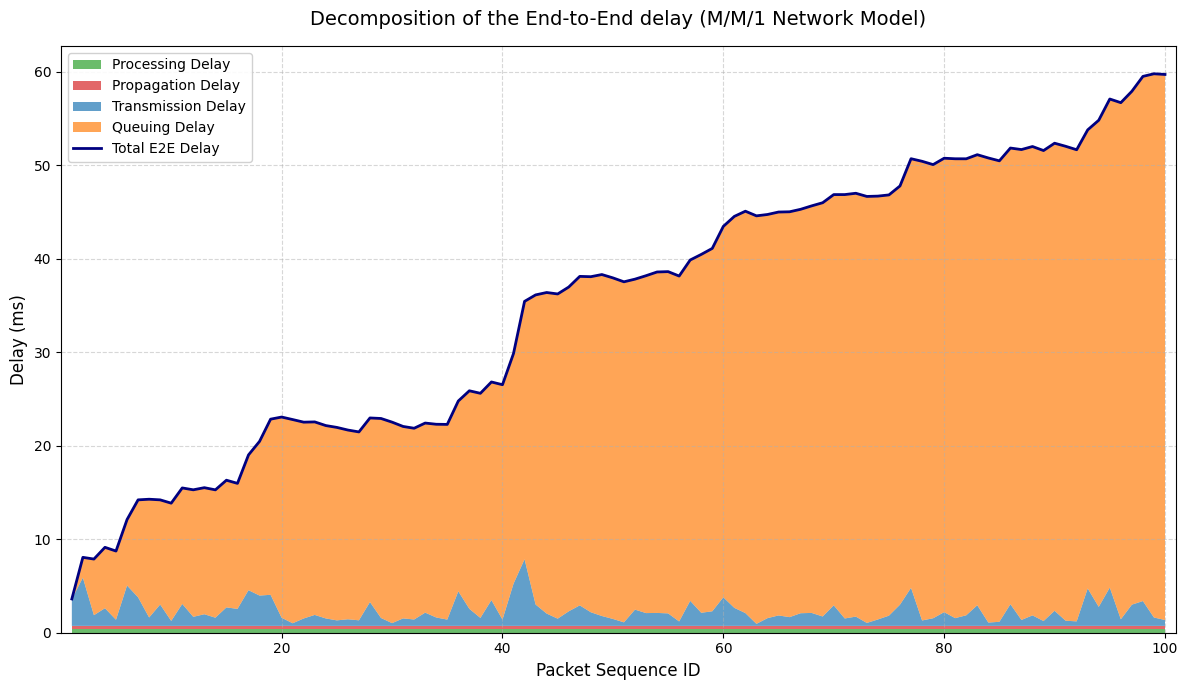


Breakdown of the last packet (ID 100):
- Processing:   0.40 ms
- Propagation:  0.33 ms
- Transmission: 0.63 ms
- Queuing:      58.34 ms
--------------------------------
= TOTAL:        59.70 ms


In [5]:
import matplotlib.pyplot as plt

# helper function to sum a specific metric across all hops for a given packet
def sum_metric_all_hops(hops_list, metric_name):
    if not isinstance(hops_list, list): return 0.0
    return sum(hop.get(metric_name, 0.0) for hop in hops_list)

# create new columns in the DataFrame for each delay component by summing across all hops
df['Total_Proc_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'processing_ms'))
df['Total_Prop_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'propagation_ms'))
df['Total_Trans_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'transmission_ms'))
df['Total_Queue_ms'] = df['Hops_Details'].apply(lambda x: sum_metric_all_hops(x, 'queue_ms'))

# create a stack plot to visualize the delay breakdown for each packet
plt.figure(figsize=(12, 7))

# We use plt.stackplot to create a stacked area chart where each layer represents a different delay component. 
# The order is important: we put the fixed delays at the bottom and the variable one (the queue) above.
plt.stackplot(
    df['Packet_ID'],
    df['Total_Proc_ms'],
    df['Total_Prop_ms'],
    df['Total_Trans_ms'],
    df['Total_Queue_ms'],
    labels=['Processing Delay', 'Propagation Delay', 'Transmission Delay', 'Queuing Delay'],
    colors=['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e'], 
    alpha=0.7
)

# We add a line above everything to mark the Total Delay
plt.plot(df['Packet_ID'], df['Total_Delay_ms'], color='navy', linewidth=2, label='Total E2E Delay')

plt.title("Decomposition of the End-to-End delay (M/M/1 Network Model)", fontsize=14, pad=15)
plt.xlabel("Packet Sequence ID", fontsize=12)
plt.ylabel("Delay (ms)", fontsize=12)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.margins(x=0.01)
plt.tight_layout()

plt.show()

# Final control print to see the relative weights on the last package
last_pkt = df.iloc[-1]
print(f"\nBreakdown of the last packet (ID {last_pkt['Packet_ID']}):")
print(f"- Processing:   {last_pkt['Total_Proc_ms']:.2f} ms")
print(f"- Propagation:  {last_pkt['Total_Prop_ms']:.2f} ms")
print(f"- Transmission: {last_pkt['Total_Trans_ms']:.2f} ms")
print(f"- Queuing:      {last_pkt['Total_Queue_ms']:.2f} ms")
print(f"--------------------------------")
print(f"= TOTAL:        {last_pkt['Total_Delay_ms']:.2f} ms")